## Air Quality Classification

In [54]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [55]:
df = pd.read_csv("updated_pollution_dataset.csv")
df.head()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density,Air Quality
0,29.8,59.1,5.2,17.9,18.9,9.2,1.72,6.3,319,Moderate
1,28.3,75.6,2.3,12.2,30.8,9.7,1.64,6.0,611,Moderate
2,23.1,74.7,26.7,33.8,24.4,12.6,1.63,5.2,619,Moderate
3,27.1,39.1,6.1,6.3,13.5,5.3,1.15,11.1,551,Good
4,26.5,70.7,6.9,16.0,21.9,5.6,1.01,12.7,303,Good


### Data Understanding

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Temperature                    5000 non-null   float64
 1   Humidity                       5000 non-null   float64
 2   PM2.5                          5000 non-null   float64
 3   PM10                           5000 non-null   float64
 4   NO2                            5000 non-null   float64
 5   SO2                            5000 non-null   float64
 6   CO                             5000 non-null   float64
 7   Proximity_to_Industrial_Areas  5000 non-null   float64
 8   Population_Density             5000 non-null   int64  
 9   Air Quality                    5000 non-null   object 
dtypes: float64(8), int64(1), object(1)
memory usage: 390.8+ KB


Interpreting df.info() output
- total data we have 5000, total columns 10
- there is no null value in the data
- All the columns have numeric values, except for the Air Quality which is [object] categorical value
- we will eventually convert the categorical value by encoding and making it numeric,

In [57]:
df.describe()

,Temperature,Humidity,PM2.5,PM10,NO2,SO2,CO,Proximity_to_Industrial_Areas,Population_Density
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,30.029020,70.056120,20.142140,30.218360,26.412100,10.014820,1.500354,8.425400,497.423800
std,6.720661,15.863577,24.554546,27.349199,8.895356,6.750303,0.546027,3.610944,152.754084
min,13.400000,36.000000,0.000000,-0.200000,7.400000,-6.200000,0.650000,2.500000,188.000000
25%,25.100000,58.300000,4.600000,12.300000,20.100000,5.100000,1.030000,5.400000,381.000000
50%,29.000000,69.800000,12.000000,21.700000,25.300000,8.000000,1.410000,7.900000,494.000000
75%,34.000000,80.300000,26.100000,38.100000,31.900000,13.725000,1.840000,11.100000,600.000000
max,58.600000,128.100000,295.000000,315.800000,64.900000,44.900000,3.720000,25.800000,957.000000


Interpreting the df.describe() output

- Humidity:-
    - avg 70%, min 36%, max 128% > 100% so, that is false data 
- PM2.5:-
    - the avg is 20 but the max is 295 which is huge jump
    - the 75th percentile is 26, it means most of the value are lower 
    - finally, the evaluation of the column PM2.5 suggest the presence of huge outlier and skewed data.
- PM10:-
    - the avg 30 and max 315 has huge gap,
    - 75th quartile 38, so most of the value are smaller 
    - min value is -0.2 which is false value

- similarly other columns value have been thoroughly analyzed

In [58]:
df["Air Quality"].value_counts()

Air Quality
Good         2000
Moderate     1500
Poor         1000
Hazardous     500
Name: count, dtype: int64

### EDA (Exploratory Data Analysis)

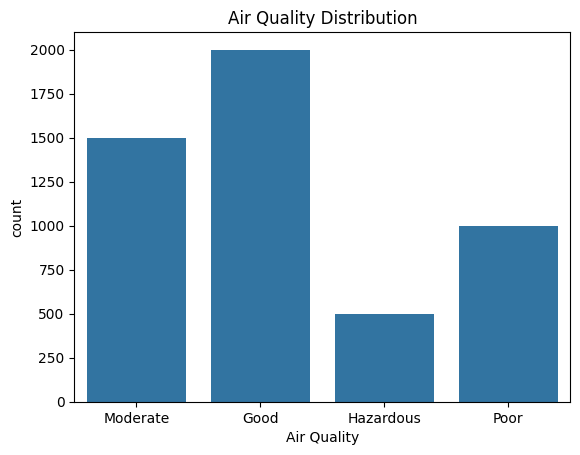

In [59]:
# at first lets see target data is balance?
sns.countplot(x="Air Quality", data=df)
plt.title("Air Quality Distribution")
plt.show()

Data seems imbalance 
- Good and moderate have more records than the hazardous and poor

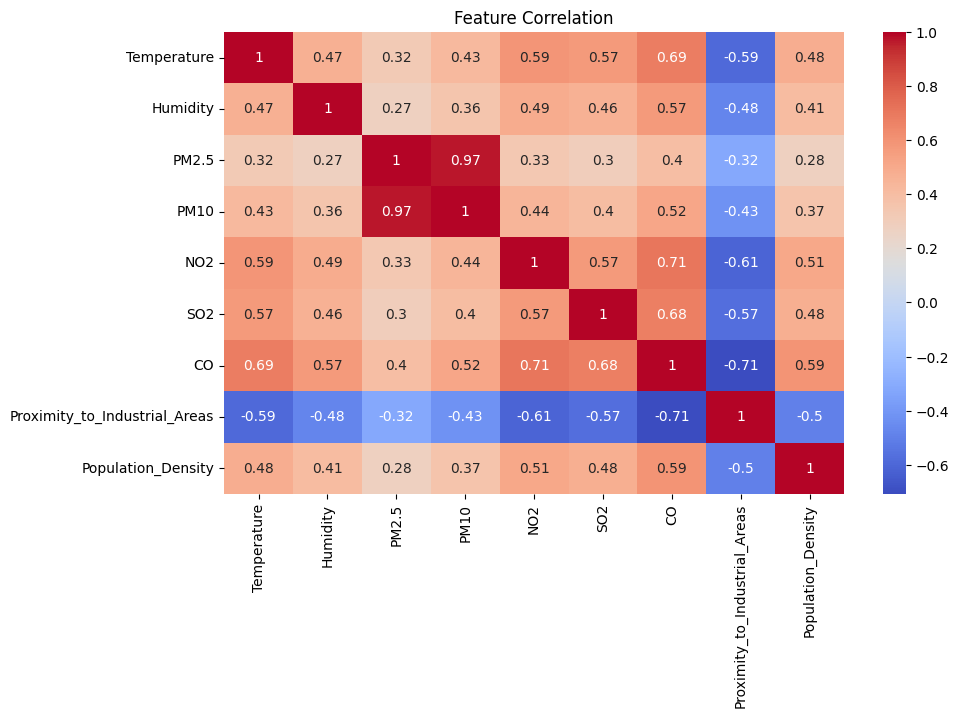

In [60]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [61]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
a = LabelEncoder()

df["Air Quality"] = a.fit_transform(df["Air Quality"])

print("Value converted into :")
for value, encoded in zip(a.classes_, a.transform(a.classes_)):
    print(f"{value} → {encoded}")

Value converted into :
Good → 0
Hazardous → 1
Moderate → 2
Poor → 3


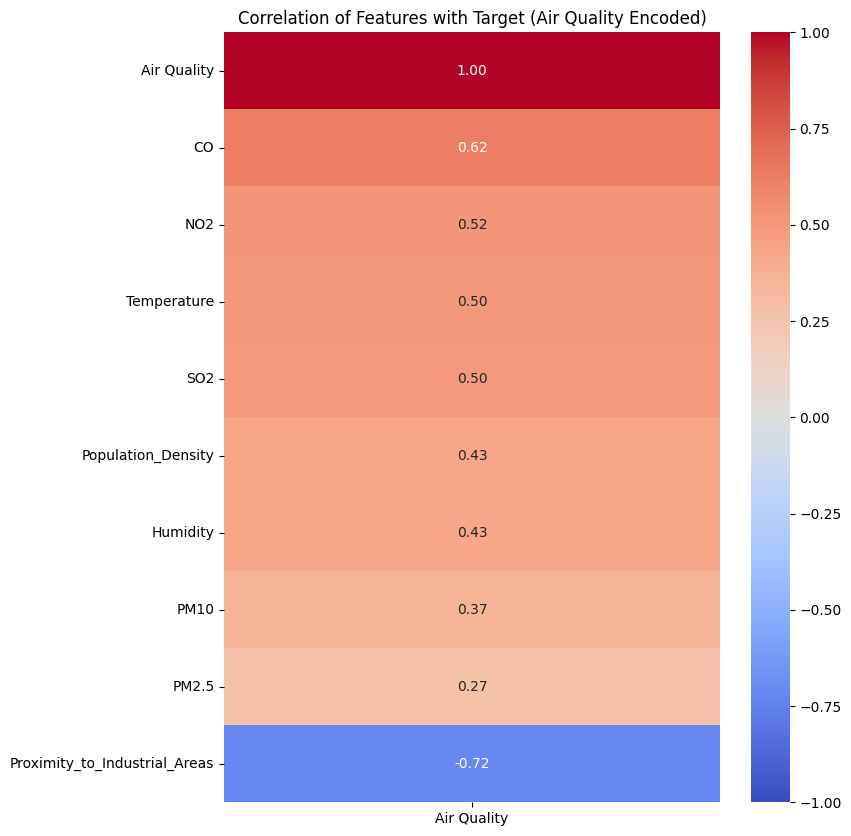

In [62]:
plt.figure(figsize=(8, 10))

corr_with_target = df.corr(numeric_only=True)[['Air Quality']].sort_values(
    by='Air Quality', 
    ascending=False
)

sns.heatmap(corr_with_target, 
            annot=True, 
            cmap='coolwarm', 
            fmt='.2f',
            vmin=-1, 
            vmax=1)

plt.title("Correlation of Features with Target (Air Quality Encoded)")
plt.show()

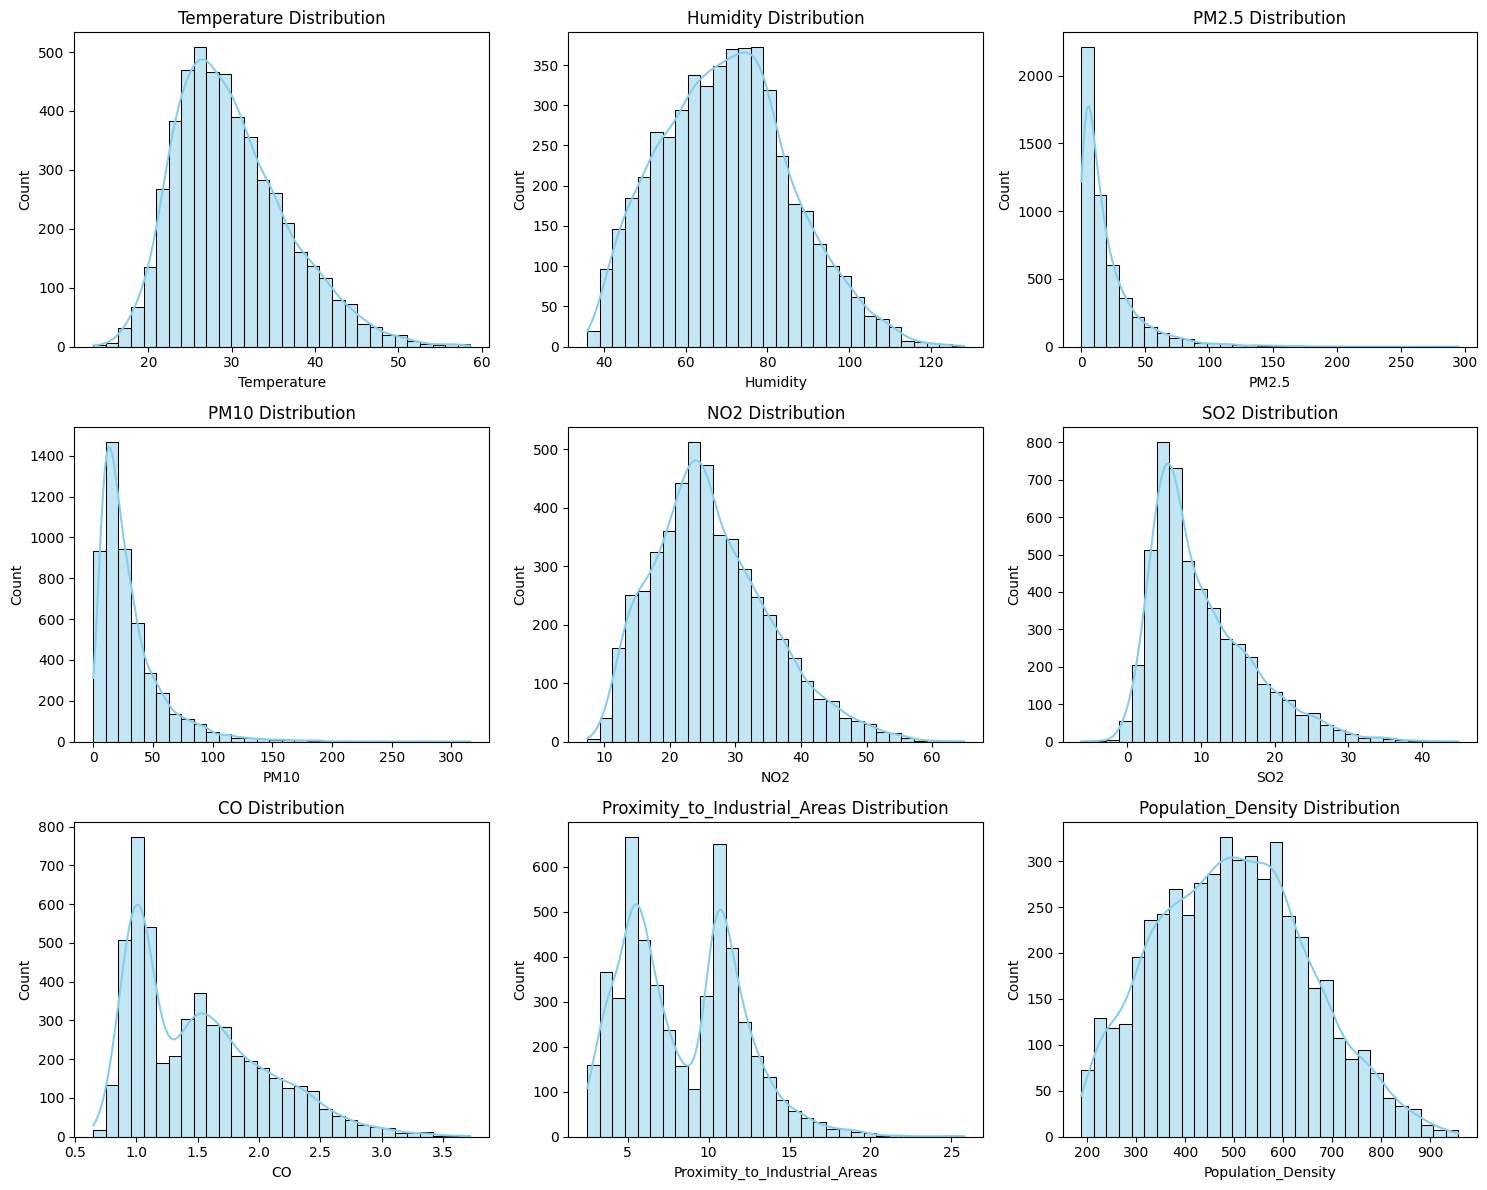

In [63]:
numerical_cols = ['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO','Proximity_to_Industrial_Areas', 'Population_Density']

plt.figure(figsize=(15, 12))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f"{col} Distribution")
    plt.xlabel(col)

plt.tight_layout()
plt.show()

In [64]:
X = df.drop(['Air Quality'], axis=1)
y = df['Air Quality']

print(X.columns)
print("********************************************")
print(y.head())

Index(['Temperature', 'Humidity', 'PM2.5', 'PM10', 'NO2', 'SO2', 'CO',
       'Proximity_to_Industrial_Areas', 'Population_Density'],
      dtype='object')
********************************************
0    2
1    2
2    2
3    0
4    0
Name: Air Quality, dtype: int64


In [65]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
)

print(X_train.shape)
print("_______________________________________________________________________________________")
print(X_test.shape)
print("_______________________________________________________________________________________")
print(y_train.shape)
print("_______________________________________________________________________________________")
print(y_test.shape)

(4000, 9)
_______________________________________________________________________________________
(1000, 9)
_______________________________________________________________________________________
(4000,)
_______________________________________________________________________________________
(1000,)


In [66]:
for col in numerical_cols:
    lower = X_train[col].quantile(0.01)  
    upper = X_train[col].quantile(0.99)
    
    X_train[col] = np.clip(X_train[col], lower, upper)
    X_test[col]  = np.clip(X_test[col], lower, upper)

print(X_train.describe())

       Temperature     Humidity        PM2.5         PM10         NO2  \
count  4000.000000  4000.000000  4000.000000  4000.000000  4000.00000   
mean     30.030530    70.047865    19.998445    30.092245    26.37896   
std       6.614521    15.717383    22.992968    25.772031     8.74118   
min      18.299000    40.399000     0.200000     3.700000    11.30000   
25%      25.100000    58.300000     4.600000    12.400000    20.10000   
50%      29.000000    69.900000    12.000000    21.700000    25.20000   
75%      34.100000    80.400000    26.400000    38.500000    31.80000   
max      49.004000   109.100000   120.502000   137.512000    50.80100   

               SO2           CO  Proximity_to_Industrial_Areas  \
count  4000.000000  4000.000000                    4000.000000   
mean      9.969150     1.496655                       8.426850   
std       6.495871     0.533151                       3.570139   
min       0.500000     0.790000                       2.700000   
25%       5.

In [67]:
# as we saw in the EDA there was ont redundant column so lets remove it 
X_train = X_train.drop(['PM10'], axis=1)
X_test  = X_test.drop(['PM10'], axis=1)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [69]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score

print("decision tree")
dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)   # max_depth=10 to control complexity
dt_model.fit(X_train_scaled, y_train)

decision tree


,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [72]:
y_pred_dt = dt_model.predict(X_test_scaled)

print("Decision Tree Accuracy:", round(accuracy_score(y_test, y_pred_dt), 4))
print("\nDecision Tree Report:")
print(classification_report(y_test, y_pred_dt, target_names=a.classes_))

Decision Tree Accuracy: 0.934

Decision Tree Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       409
   Hazardous       0.81      0.83      0.82       111
    Moderate       0.96      0.96      0.96       294
        Poor       0.84      0.82      0.83       186

    accuracy                           0.93      1000
   macro avg       0.90      0.90      0.90      1000
weighted avg       0.93      0.93      0.93      1000



In [73]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [74]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [76]:
print("Random Forest Accuracy:", round(accuracy_score(y_test, y_pred_rf), 4))
print("\nRandom Forest Report:")
print(classification_report(y_test, y_pred_rf, target_names=a.classes_))

Random Forest Accuracy: 0.959

Random Forest Report:
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00       409
   Hazardous       0.92      0.87      0.90       111
    Moderate       0.96      0.97      0.97       294
        Poor       0.88      0.90      0.89       186

    accuracy                           0.96      1000
   macro avg       0.94      0.94      0.94      1000
weighted avg       0.96      0.96      0.96      1000



In [79]:
import joblib

joblib.dump(rf_model, 'air_quality_rf_model.pkl')

['air_quality_rf_model.pkl']

In [80]:
# to scale the new data as the same way as the training data lets dump the scaler
# to convert the prediction lets dump the label encoder as well 

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(a, 'label_encoder.pkl')

['label_encoder.pkl']